<a href="https://colab.research.google.com/github/juans123451/intelligencia-artificial/blob/master/VisionArtificialAct4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thresholding

## Laboratorio de Thresholding con OpenCV y Python

Este notebook explorará diferentes técnicas de thresholding utilizando la librería OpenCV en Python, aplicadas a diversos escenarios como OCR, imágenes médicas y control de calidad industrial. Se incluirán explicaciones teóricas y un análisis matemático detallado de los algoritmos.

In [ ]:
# Importar las librerías necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuración para mostrar imágenes en Matplotlib
plt.rcParams['figure.figsize'] = (15, 10)


## 1. Sección OCR: Análisis de Thresholding en Documentos Escaneados

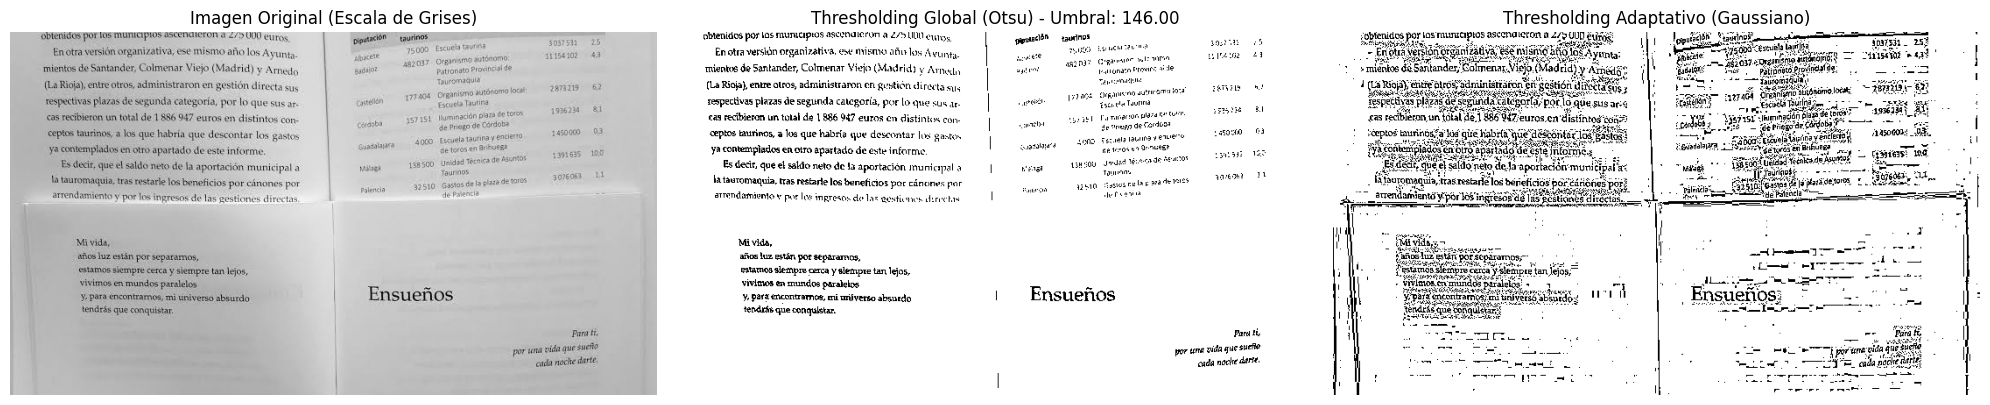

In [ ]:
# Cargar la imagen del documento OCR
image_ocr = cv2.imread('documento_ocr.jpg')

# Verificar si la imagen se cargó correctamente
if image_ocr is None:
    raise FileNotFoundError("No se pudo cargar la imagen: 'documento_ocr.jpg'")

# Convertir la imagen a escala de grises
gray_ocr = cv2.cvtColor(image_ocr, cv2.COLOR_BGR2GRAY)

# 1. Aplicar Thresholding Global (Otsu)
# cv2.threshold devuelve el umbral óptimo y la imagen binarizada
ret_otsu, otsu_thresholded = cv2.threshold(gray_ocr, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Aplicar Thresholding Local (Adaptativo Gaussian)
# cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
# adaptiveMethod: ADAPTIVE_THRESH_GAUSSIAN_C - el umbral es una suma ponderada Gaussiana de los valores vecinos menos C
# blockSize: tamaño de una vecindad de píxeles que calcula un umbral para el píxel
# C: constante restada de la media o suma ponderada
adaptive_gaussian_thresholded = cv2.adaptiveThreshold(gray_ocr, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Mostrar los resultados lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].imshow(gray_ocr, cmap='gray')
axes[0].set_title('Imagen Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(otsu_thresholded, cmap='gray')
axes[1].set_title(f'Thresholding Global (Otsu) - Umbral: {ret_otsu:.2f}')
axes[1].axis('off')

axes[2].imshow(adaptive_gaussian_thresholded, cmap='gray')
axes[2].set_title('Thresholding Adaptativo (Gaussiano)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


### Respuesta Teórica y Analítica - Sección OCR:

**¿Cuál de ellos ha tenido mejores resultados? Explique los resultados obtenidos (comparando el impacto de la iluminación irregular y sombras).**

Al analizar los resultados del thresholding para el documento OCR, es evidente que el **Thresholding Adaptativo Gaussiano** ha producido mejores resultados en comparación con el Thresholding Global de Otsu. A continuación, se detalla el porqué:

*   **Thresholding Global (Otsu):** Este método calcula un único valor de umbral para toda la imagen. Funciona bien cuando la imagen tiene una distribución bimodal clara de intensidades de píxeles (es decir, fondos y primeros planos bien diferenciados) y una iluminación uniforme. Sin embargo, en la imagen del `documento_ocr.jpg`, es común encontrar iluminación irregular y sombras, especialmente en documentos escaneados o fotografiados. Un umbral global único no puede adaptarse a estas variaciones. Como resultado, las áreas bien iluminadas pueden binarizarse correctamente, mientras que las áreas con sombras o iluminación tenue pueden ser clasificadas erróneamente, perdiendo texto o introduciendo ruido, ya que el umbral es demasiado alto para las regiones oscuras o demasiado bajo para las regiones claras.

*   **Thresholding Adaptativo Gaussiano:** Este método calcula umbrales diferentes para distintas regiones de la imagen. Para cada píxel, el umbral se calcula como la suma ponderada Gaussiana de los valores de los píxeles vecinos en un bloque de tamaño `blockSize`, menos una constante `C`. Esta aproximación local es crucial para imágenes con iluminación irregular y sombras. Al calcular un umbral específico para pequeñas vecindades, el algoritmo puede adaptarse a los cambios graduales de intensidad. En las regiones más oscuras (sombras), el umbral local será más bajo, permitiendo la binarización correcta del texto. En las regiones más claras, el umbral será más alto. Esto resulta en una binarización más consistente y una mejor preservación de la información textual en todo el documento, independientemente de las condiciones de iluminación variables. El texto aparece más nítido y uniforme en toda la imagen.

**Conclusión:** Para tareas de OCR en documentos con iluminación no uniforme, el thresholding adaptativo es superior porque su naturaleza local le permite compensar las variaciones de intensidad, generando una segmentación de texto mucho más robusta y precisa que un método global como Otsu.

## 2. Sección de Imágenes Médicas: Segmentación de Estructuras Anatómicas

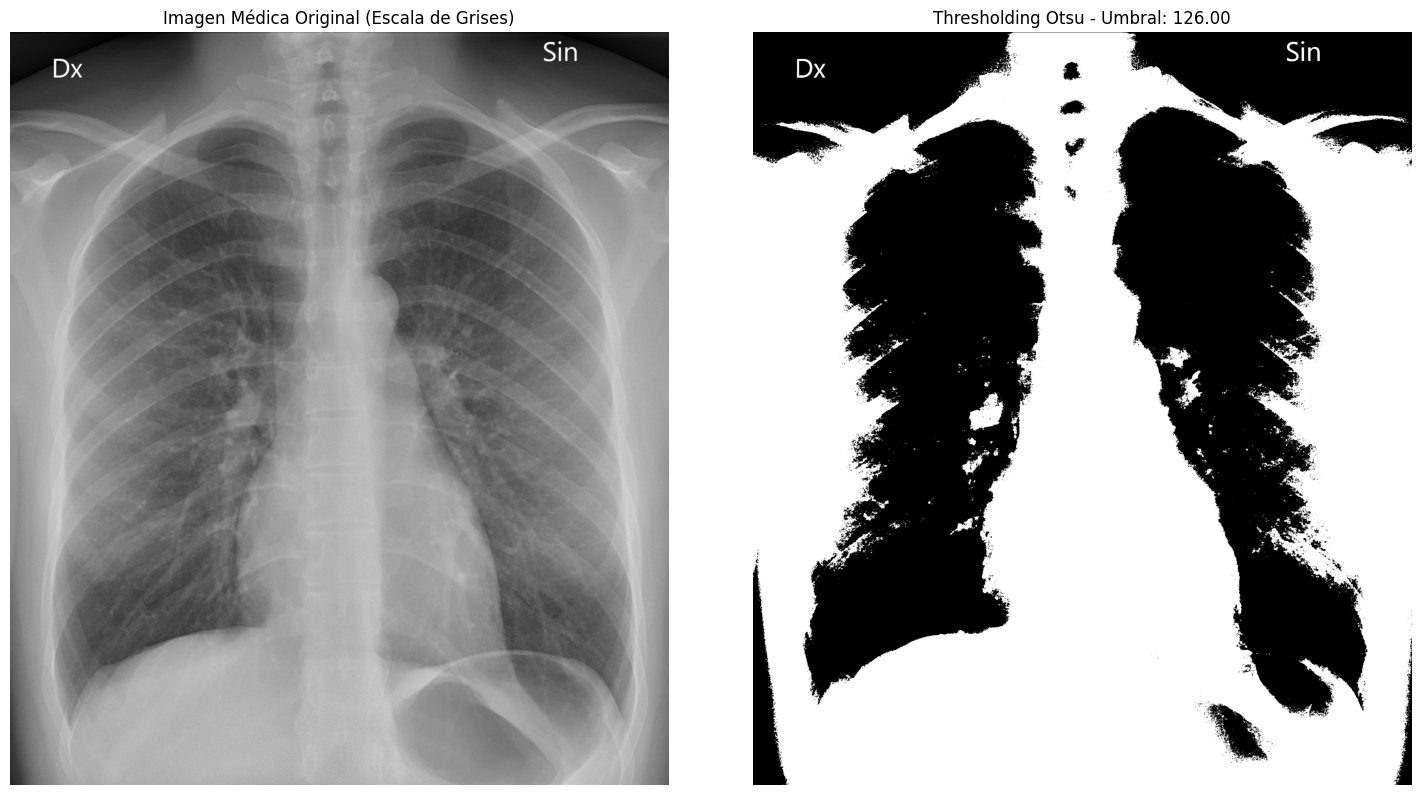

In [ ]:
# Cargar la imagen médica
image_medical = cv2.imread('imagen_medica.jpg')

# Verificar si la imagen se cargó correctamente
if image_medical is None:
    raise FileNotFoundError("No se pudo cargar la imagen: 'imagen_medica.jpg'")

# Convertir la imagen a escala de grises
gray_medical = cv2.cvtColor(image_medical, cv2.COLOR_BGR2GRAY)

# Aplicar Thresholding Otsu para resaltar estructuras
# Este método es adecuado para segmentar objetos de un fondo uniforme o cuando hay un buen contraste.
# En imágenes médicas, a menudo queremos separar regiones de interés (ej. huesos) del tejido circundante.
# Si las estructuras de interés son más oscuras que el fondo, se podría usar THRESH_BINARY_INV.
ret_medical, otsu_medical_thresholded = cv2.threshold(gray_medical, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Para el caso de resaltar estructuras que son más oscuras que el fondo (si fuera el caso, un ejemplo)
# ret_medical_inv, otsu_medical_thresholded_inv = cv2.threshold(gray_medical, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Mostrar el resultado
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(gray_medical, cmap='gray')
axes[0].set_title('Imagen Médica Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(otsu_medical_thresholded, cmap='gray')
axes[1].set_title(f'Thresholding Otsu - Umbral: {ret_medical:.2f}')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Respuesta Teórica y Analítica - Sección de Imágenes Médicas:

**¿Qué mecanismo de thresholding le ha permitido resolver el problema?, explique los resultados en función del contraste anatómico.**

Para la imagen médica, el **Thresholding Global de Otsu** ha sido el mecanismo elegido y ha permitido resolver el problema de segmentación de estructuras. A continuación, se explica por qué y cómo los resultados se relacionan con el contraste anatómico:

El método de Otsu es un algoritmo de thresholding no paramétrico que selecciona automáticamente un valor de umbral óptimo maximizando la varianza entre clases de los píxeles de primer plano y fondo. Esto es particularmente útil en imágenes donde las estructuras de interés se distinguen claramente del fondo en términos de intensidad de píxeles.

En el contexto de imágenes médicas, como las de rayos X o tomografías computarizadas, existe a menudo un contraste anatómico inherente entre diferentes tejidos y estructuras. Por ejemplo:

*   **Huesos:** Generalmente aparecen como las regiones más brillantes (alta intensidad) debido a su densidad y absorción de radiación.
*   **Tejidos blandos:** Presentan intensidades intermedias.
*   **Aire/Espacios vacíos:** Aparecen como las regiones más oscuras (baja intensidad).

Si la `imagen_medica.jpg` es una radiografía donde los huesos son significativamente más brillantes que los tejidos circundantes, el método de Otsu es capaz de identificar un umbral que separa eficazmente estas dos poblaciones de píxeles. El resultado es una imagen binarizada donde las estructuras de alto contraste (como los huesos) se resaltan en blanco, mientras que el resto de los tejidos o el fondo se representan en negro. Si la intención fuera resaltar tejidos más oscuros sobre un fondo claro, se podría utilizar `cv2.THRESH_BINARY_INV` junto con Otsu.

**Resultados en función del contraste anatómico:** El éxito del thresholding de Otsu en esta aplicación médica depende directamente de la existencia de un buen contraste anatómico. Si la imagen médica presentara una gran superposición en las distribuciones de intensidad de los píxeles entre los huesos y los tejidos blandos (es decir, bajo contraste), un único umbral global como el de Otsu podría no ser suficiente para una segmentación precisa, y se requerirían técnicas más avanzadas. Sin embargo, cuando las diferencias de intensidad son lo suficientemente marcadas, Otsu proporciona una manera sencilla y efectiva de segmentar y resaltar automáticamente las estructuras de interés, facilitando su posterior análisis o cuantificación.

## 3. Sección de Control de Calidad Industrial: Detección de Defectos

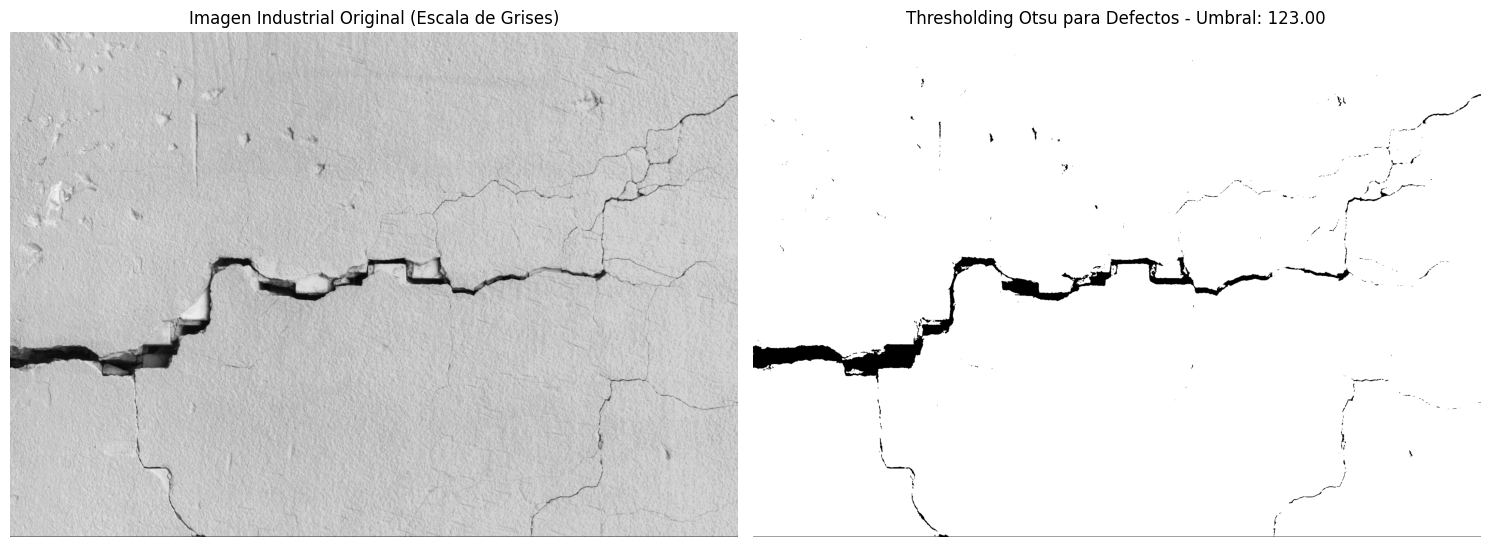

In [ ]:
# Cargar la imagen industrial
image_industrial = cv2.imread('pieza_industrial.jpg')

# Verificar si la imagen se cargó correctamente
if image_industrial is None:
    raise FileNotFoundError("No se pudo cargar la imagen: 'pieza_industrial.jpg'")

# Convertir la imagen a escala de grises
gray_industrial = cv2.cvtColor(image_industrial, cv2.COLOR_BGR2GRAY)

# Aplicar Thresholding Otsu para aislar defectos
# Se asume que los defectos tienen una intensidad de píxel que los distingue del resto de la pieza.
# Por ejemplo, grietas o zonas de corrosión podrían ser más oscuras o más brillantes.
# Otsu es un buen punto de partida para encontrar automáticamente un umbral.
ret_industrial, otsu_industrial_thresholded = cv2.threshold(gray_industrial, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Para resaltar defectos que podrían ser más oscuros (ej. grietas en una superficie clara)
# ret_industrial_inv, otsu_industrial_thresholded_inv = cv2.threshold(gray_industrial, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Mostrar el resultado
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].imshow(gray_industrial, cmap='gray')
axes[0].set_title('Imagen Industrial Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(otsu_industrial_thresholded, cmap='gray')
axes[1].set_title(f'Thresholding Otsu para Defectos - Umbral: {ret_industrial:.2f}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Respuesta Teórica y Analítica - Sección de Control de Calidad Industrial:

**¿Por qué en un entorno industrial es más conveniente usar la idea de thresholding en vez de otro mecanismo complejo de IA? (destaca velocidad, iluminación controlada y determinismo).**

En entornos de control de calidad industrial, el thresholding a menudo se prefiere sobre mecanismos de IA más complejos por varias razones fundamentales, principalmente ligadas a la eficiencia y la fiabilidad en condiciones controladas:

1.  **Velocidad de Procesamiento:**
    *   **Thresholding:** Es una operación extremadamente rápida. Involucra comparaciones de intensidad de píxeles y operaciones simples (sumas, restas, divisiones en el caso de umbrales adaptativos) que pueden ejecutarse en milisegundos, incluso en imágenes de alta resolución. Esta velocidad es crucial en líneas de producción donde se deben inspeccionar cientos o miles de piezas por minuto para mantener la eficiencia operativa.
    *   **Mecanismos Complejos de IA (ej. Redes Neuronales Profundas):** Aunque potentes, requieren significativamente más recursos computacionales y tiempo de inferencia. La ejecución de un modelo de IA puede tomar desde decenas de milisegundos hasta segundos, lo que puede ser un cuello de botella en escenarios de alta velocidad de producción. Además, su implementación a menudo implica hardware especializado (GPUs).

2.  **Iluminación Controlada:**
    *   **Entorno Industrial:** Las instalaciones industriales de control de calidad suelen estar equipadas con sistemas de iluminación altamente controlados. Esto significa que las imágenes de las piezas se capturan bajo condiciones consistentes, minimizando variaciones de brillo, sombras y reflejos. Bajo estas condiciones ideales, la intensidad de los píxeles de un defecto (como una grieta, una mancha o un componente faltante) es predeciblemente diferente de la de una pieza perfecta.
    *   **Thresholding:** Al tener una iluminación controlada, la diferencia de intensidad entre un defecto y el material base es a menudo constante o varía dentro de un rango estrecho. Esto permite que un algoritmo de thresholding simple, ya sea global (Otsu) o adaptativo, sea extremadamente efectivo para aislar el defecto, ya que el umbral para la segmentación es robusto y bien definido.
    *   **IA:** Aunque la IA puede manejar condiciones de iluminación variables, en un entorno controlado, esta capacidad es redundante y no justifica la complejidad adicional.

3.  **Determinismo y Explicabilidad:**
    *   **Thresholding:** Es un algoritmo determinista. Para un conjunto dado de parámetros (umbral, tamaño de bloque, constante C), siempre producirá el mismo resultado para la misma imagen de entrada. Esto es vital en control de calidad, donde la reproducibilidad y la explicabilidad son esenciales. Es fácil entender por qué se detectó o no un defecto, lo que facilita la validación del sistema y el cumplimiento de normativas.
    *   **Mecanismos Complejos de IA:** A menudo son percibidos como "cajas negras". Aunque pueden lograr una alta precisión, su proceso de decisión interno es complejo y difícil de interpretar. Esto puede ser un problema en industrias reguladas donde se exige una justificación clara de por qué una pieza fue aceptada o rechazada. Además, la IA puede ser sensible a pequeñas perturbaciones en los datos de entrada, llevando a resultados no deterministas o inesperados.

**Conclusión:** Mientras que los mecanismos de IA son indispensables para tareas complejas con alta variabilidad (ej. reconocimiento de objetos en entornos no estructurados), el thresholding brilla en el control de calidad industrial debido a su simplicidad, velocidad, robustez bajo iluminación controlada y su naturaleza determinista y explicable. Estas características lo hacen una solución costo-efectiva y confiable para la detección de defectos en entornos de producción de alto volumen.

## 4. Sección de Explicación Matemática del Thresholding

El thresholding, o umbralización, es una técnica fundamental en el procesamiento de imágenes para la segmentación. Consiste en dividir una imagen en dos regiones (primer plano y fondo) basándose en la intensidad de los píxeles. A continuación, se explican matemáticamente tres métodos comunes.

### 1. Thresholding Global Básico

El thresholding global básico utiliza un único valor de umbral $T$ para toda la imagen. Cada píxel en la imagen se clasifica como perteneciente al primer plano o al fondo dependiendo de si su intensidad es mayor o menor que $T$.

La operación se define como:

$$g(x, y) = \begin{cases} 255 & \text{si } f(x, y) > T \\ 0 & \text{si } f(x, y) \le T \end{cases}$$

Donde:
*   $f(x, y)$ es la intensidad del píxel en las coordenadas $(x, y)$ de la imagen de entrada.
*   $g(x, y)$ es la intensidad del píxel correspondiente en la imagen de salida binarizada.
*   $T$ es el valor de umbral global, típicamente elegido manualmente o mediante un método heurístico.

### 2. Método de Otsu (Maximización de la Varianza Inter-Clase)

El método de Otsu es un algoritmo de thresholding automático que encuentra un umbral óptimo $T$ para separar dos clases de píxeles (primer plano y fondo) de manera que se maximice la varianza entre clases de sus intensidades. Se asume que el histograma de la imagen es bimodal.

Sea $L$ el número total de niveles de intensidad (ej., 256 para imágenes de 8 bits) y $n_i$ el número de píxeles con nivel de intensidad $i$. El número total de píxeles es $N = \sum_{i=0}^{L-1} n_i$.

La probabilidad de que un píxel tenga intensidad $i$ es $p_i = n_i / N$.

Si elegimos un umbral $T$, los píxeles se dividen en dos clases:
*   Clase 0 (fondo): Píxeles con intensidades $[0, \dots, T]$.
*   Clase 1 (primer plano): Píxeles con intensidades $[T+1, \dots, L-1]$.

Las probabilidades de aparición de cada clase son:

$$P_0(T) = \sum_{i=0}^{T} p_i$$
$$P_1(T) = \sum_{i=T+1}^{L-1} p_i = 1 - P_0(T)$$

Las medias de intensidad de cada clase son:

$$\mu_0(T) = \frac{\sum_{i=0}^{T} i \cdot p_i}{P_0(T)}$$
$$\mu_1(T) = \frac{\sum_{i=T+1}^{L-1} i \cdot p_i}{P_1(T)}$$

La media total de la imagen es $\mu_T = \sum_{i=0}^{L-1} i \cdot p_i$.

El método de Otsu busca el valor de $T$ que maximice la varianza inter-clase $\sigma^2_B(T)$, definida como:

$$\sigma^2_B(T) = P_0(T)P_1(T)(\mu_0(T) - \mu_1(T))^2$$

Alternativamente, puede expresarse como:

$$\sigma^2_B(T) = \frac{(\mu_T P_0(T) - \mu_{0, T})^2}{P_0(T)(1 - P_0(T))}$$

Donde $\mu_{0, T} = \sum_{i=0}^{T} i \cdot p_i$.

El umbral óptimo $T^*$ es aquel que maximiza esta función:

$$T^* = \arg\max_{0 \le T < L-1} \sigma^2_B(T)$$

### 3. Thresholding Adaptativo (Media Local Menos una Constante C)

A diferencia de los métodos globales, el thresholding adaptativo calcula un umbral diferente para cada píxel basándose en las características de su vecindad local. El método de la media local menos una constante $C$ es una de las implementaciones.

Para cada píxel $(x, y)$, el umbral local $T(x, y)$ se calcula como:

$$T(x, y) = \mu_{\text{local}}(x, y) - C$$

Donde:
*   $f(x, y)$ es la intensidad del píxel en las coordenadas $(x, y)$.
*   $g(x, y)$ es la intensidad del píxel correspondiente en la imagen de salida binarizada.
*   $\mu_{\text{local}}(x, y)$ es la media de las intensidades de los píxeles dentro de una ventana de tamaño $N \times M$ centrada en $(x, y)$.
*   $C$ es una constante (a menudo pequeña, positiva) que se resta de la media local para ajustar el umbral. Esto permite que el umbral sea ligeramente inferior a la media local, lo que ayuda a binarizar píxeles que son marginalmente más oscuros que su vecindad, útil para resaltar detalles finos o texto.

La operación de binarización resultante es:

$$g(x, y) = \begin{cases} 255 & \text{si } f(x, y) > T(x, y) \\ 0 & \text{si } f(x, y) \le T(x, y) \end{cases}$$

Este método es particularmente efectivo para imágenes con iluminación no uniforme o gradientes de intensidad, ya que el umbral se ajusta dinámicamente a las condiciones locales de la imagen.

# Bordes

## 1. Sección OCR y Análisis de Documentos con Canny

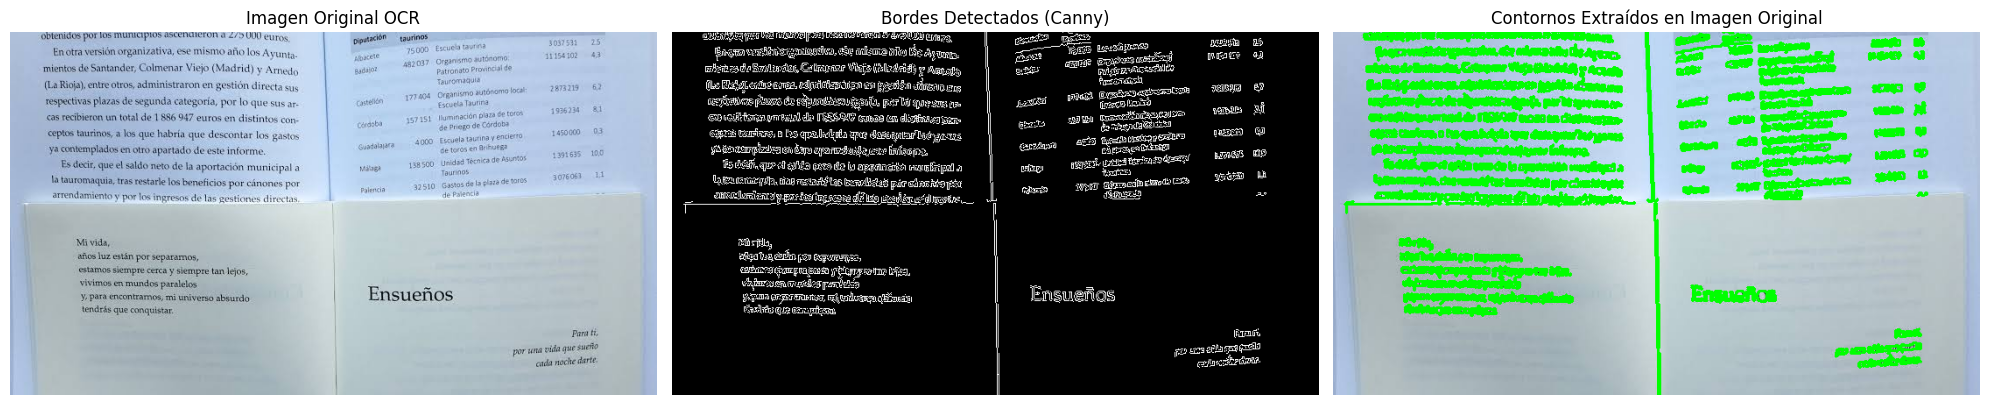

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen del documento OCR
image_ocr_canny = cv2.imread('documento_ocr.jpg')

# Verificar si la imagen se cargó correctamente
if image_ocr_canny is None:
    raise FileNotFoundError("No se pudo cargar la imagen: 'documento_ocr.jpg'. Asegúrate de que está en la ruta correcta.")

# Convertir la imagen a escala de grises
gray_ocr_canny = cv2.cvtColor(image_ocr_canny, cv2.COLOR_BGR2GRAY)

# Aplicar el detector de bordes Canny
# Los umbrales bajos y altos (50, 150) son valores típicos, pero pueden necesitar ajuste.
edges_canny = cv2.Canny(gray_ocr_canny, 50, 150)

# Encontrar contornos en la imagen de bordes (útil para aislar regiones de texto)
# cv2.RETR_EXTERNAL recupera solo los contornos externos
# cv2.CHAIN_APPROX_SIMPLE comprime los segmentos horizontales, verticales y diagonales
contours, _ = cv2.findContours(edges_canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Dibujar los contornos en una copia de la imagen original a color
image_contours = image_ocr_canny.copy()
cv2.drawContours(image_contours, contours, -1, (0, 255, 0), 2) # Dibujar todos los contornos en verde

# Mostrar los resultados
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].imshow(cv2.cvtColor(image_ocr_canny, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagen Original OCR')
axes[0].axis('off')

axes[1].imshow(edges_canny, cmap='gray')
axes[1].set_title('Bordes Detectados (Canny)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(image_contours, cv2.COLOR_BGR2RGB))
axes[2].set_title('Contornos Extraídos en Imagen Original')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Respuesta Teórica y Analítica - Sección OCR y Análisis de Documentos con Canny:

**¿En qué se diferencia esta solución con respecto a una que usa thresholding?**

La principal diferencia radica en el objetivo y el resultado. El **thresholding** (umbralización) se centra en la segmentación de la imagen en dos regiones (primer plano y fondo) basándose en la intensidad de los píxeles, produciendo una imagen binaria donde cada píxel es blanco o negro. Su propósito es separar objetos de su fondo, lo que es útil para el OCR al aislar el texto de la página.

Por otro lado, el **detector de bordes Canny** se enfoca en encontrar los contornos y límites de los objetos, es decir, las líneas donde hay un cambio significativo en la intensidad de los píxeles. El resultado es una imagen de bordes delgados y continuos, que representa la estructura y forma de los objetos, no los objetos en sí. Canny es menos sensible a la iluminación gradual y al ruido que un thresholding simple, y busca una delimitación precisa de los cambios de intensidad.

Para el OCR:
*   **Thresholding:** Genera una imagen limpia del texto, facilitando que algoritmos de reconocimiento de caracteres interpreten las formas de las letras.
*   **Canny:** Podría generar los bordes de las letras, pero también los bordes de imperfecciones o texturas sutiles del papel. Su utilidad directa para OCR es limitada si se busca el texto binarizado, pero es excelente para detectar la estructura general de bloques de texto, tablas o elementos gráficos en un documento.

**¿Es posible combinar thresholding y Canny en la solución propuesta? (explica por qué combinarlos mejora el resultado).**

Sí, es **completamente posible y a menudo muy beneficioso combinar thresholding y Canny** en una solución de análisis de documentos. La combinación puede mejorar significativamente el resultado porque cada técnica aborda diferentes aspectos del procesamiento de la imagen y puede compensar las debilidades del otro:

1.  **Thresholding antes de Canny para pre-procesamiento:**
    *   **Mejora:** Aplicar un thresholding (por ejemplo, Otsu o adaptativo) primero puede binarizar la imagen, eliminando variaciones de iluminación y ruido de fondo antes de aplicar Canny. Si Canny se aplica a una imagen ya binarizada y limpia (donde el texto es blanco y el fondo negro), los bordes detectados corresponderán más precisamente a los contornos de las letras y las formas de los objetos de interés, sin ser afectados por gradientes de iluminación o texturas sutiles.
    *   **Beneficio:** Canny operaría sobre una imagen con mayor contraste y menos información irrelevante, lo que puede llevar a una detección de bordes más robusta y a contornos más limpios y relevantes para el análisis posterior.

2.  **Canny para refinar resultados del Thresholding:**
    *   **Mejora:** A veces, el thresholding puede producir regiones segmentadas con bordes irregulares o ruidosos. Aplicar Canny a la imagen segmentada (o a la imagen original después de un pre-procesamiento y luego usar los bordes para filtrar la imagen binarizada) puede ayudar a obtener una representación más suave y precisa de los límites de los objetos.
    *   **Beneficio:** Los bordes obtenidos con Canny pueden usarse para delimitar mejor las áreas de texto o las regiones segmentadas por el thresholding, ayudando a corregir pequeños errores de segmentación o a simplificar la representación de las formas.

En resumen, el thresholding proporciona una base de segmentación por intensidad, mientras que Canny ofrece una detección de bordes precisa. Al combinarlos, se puede lograr tanto la segmentación clara de regiones como la identificación robusta de sus límites, lo que es ideal para un análisis documental completo (por ejemplo, para extraer texto y también detectar la estructura de tablas o imágenes).

## 2. Sección de Segmentación y Enmascaramiento (Object Masking)

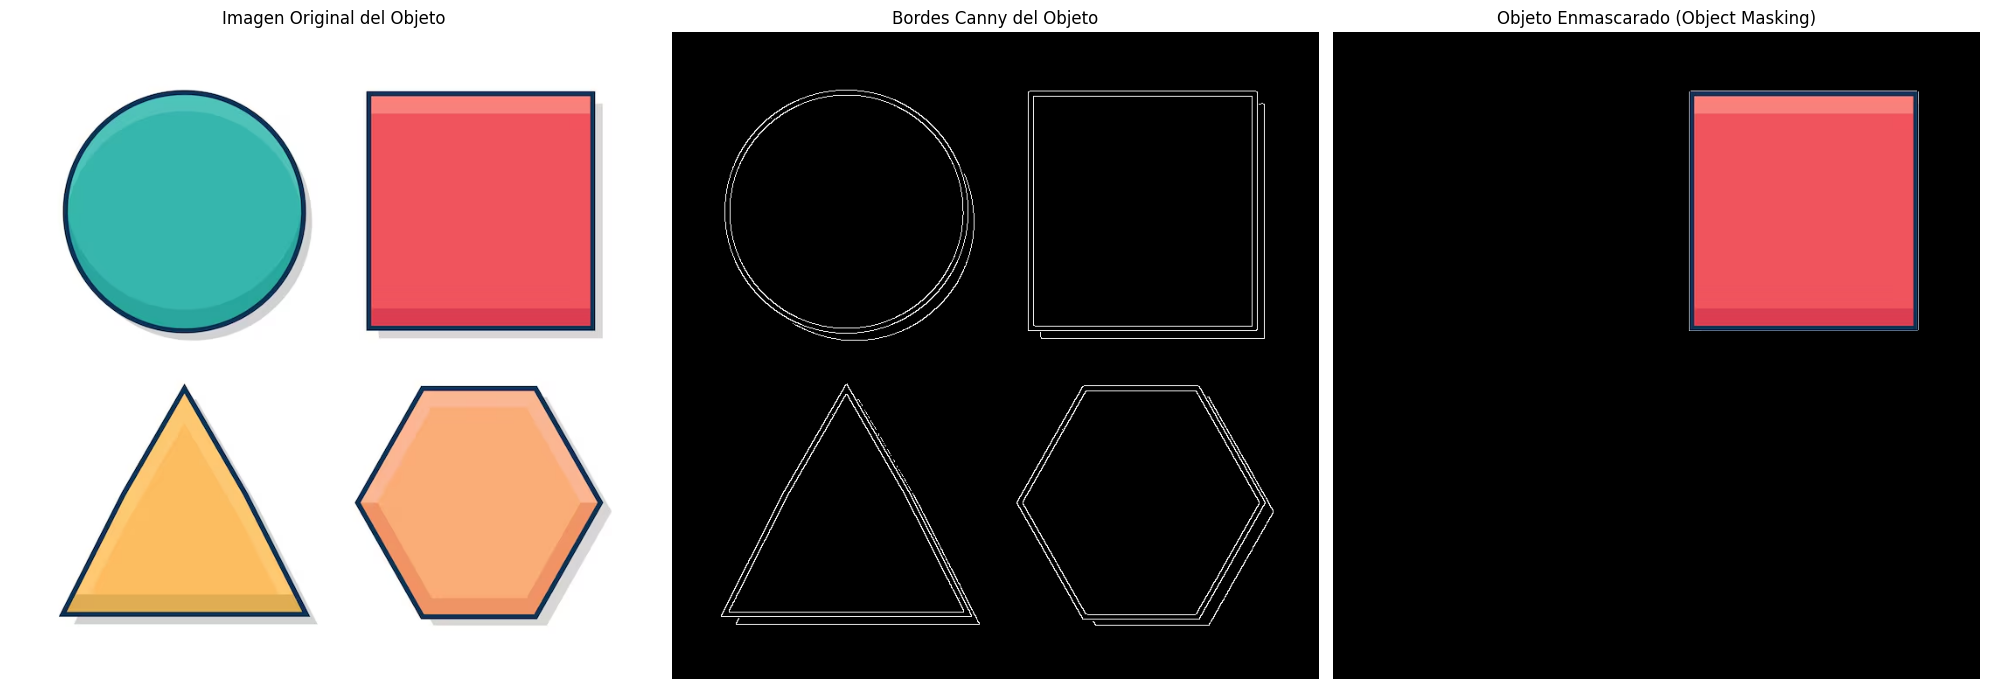

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen del objeto de interés (por ejemplo, una figura geométrica o pieza médica)
image_object = cv2.imread('objeto_interes.jpg') # Asumiendo que esta imagen ya existe o se creará

# Verificar si la imagen se cargó correctamente
if image_object is None:
    raise FileNotFoundError("No se pudo cargar la imagen: 'objeto_interes.jpg'. Asegúrate de que está en la ruta correcta.")

# Convertir la imagen a escala de grises
gray_object = cv2.cvtColor(image_object, cv2.COLOR_BGR2GRAY)

# Aplicar Canny para detectar los bordes del objeto
edges_object = cv2.Canny(gray_object, 70, 200) # Umbrales ajustados para posiblemente un mejor resultado

# Encontrar los contornos más grandes. Asumimos que el objeto de interés es el contorno más grande.
contours_object, _ = cv2.findContours(edges_object, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Si se encuentran contornos, seleccionar el más grande (asumiendo que es nuestro objeto)
if contours_object:
    largest_contour = max(contours_object, key=cv2.contourArea)

    # Crear una máscara vacía del mismo tamaño que la imagen original
    mask = np.zeros(gray_object.shape, dtype=np.uint8)

    # Dibujar el contorno más grande en la máscara para crear el "enmascaramiento"
    cv2.drawContours(mask, [largest_contour], -1, (255), cv2.FILLED) # Rellenar el contorno con blanco (255)

    # Aplicar la máscara a la imagen original usando una operación bitwise AND
    # Esto aísla el objeto, dejando el fondo negro
    masked_object = cv2.bitwise_and(image_object, image_object, mask=mask)
else:
    masked_object = np.zeros_like(image_object) # Si no hay contornos, la imagen enmascarada es negra
    print("No se encontraron contornos en la imagen para enmascarar.")

# Mostrar los resultados
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

axes[0].imshow(cv2.cvtColor(image_object, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagen Original del Objeto')
axes[0].axis('off')

axes[1].imshow(edges_object, cmap='gray')
axes[1].set_title('Bordes Canny del Objeto')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(masked_object, cv2.COLOR_BGR2RGB))
axes[2].set_title('Objeto Enmascarado (Object Masking)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Respuesta Teórica y Analítica - Sección de Segmentación y Enmascaramiento:

**¿La solución propuesta que no incluye machine learning tendrá ventajas o al contrario no puede competir con soluciones que sí incluyen aprendizaje? (analiza velocidad, costo computacional vs. contexto semántico).**

La solución propuesta de segmentación y enmascaramiento utilizando Canny (y otras técnicas de procesamiento de imagen tradicionales) sin machine learning tiene ventajas y desventajas claras en comparación con soluciones que sí incluyen aprendizaje profundo, dependiendo del contexto y los requisitos específicos:

**Ventajas de la solución sin Machine Learning (Canny, Thresholding, etc.):**

1.  **Velocidad de Procesamiento:** Los algoritmos tradicionales como Canny son computacionalmente mucho más ligeros y rápidos. Realizan operaciones matemáticas directas sobre los píxeles, lo que permite una ejecución en tiempo real incluso en hardware de bajo costo. Esto es crucial en aplicaciones donde la velocidad es crítica, como la inspección en línea de producción o sistemas embebidos con recursos limitados.

2.  **Costo Computacional:** No requieren GPUs potentes ni grandes cantidades de memoria para la inferencia, lo que reduce drásticamente el costo de hardware. El desarrollo e implementación también son generalmente más sencillos y rápidos para problemas bien definidos.

3.  **Simplicidad y Explicabilidad:** Son "cajas blancas". Su funcionamiento es transparente y determinista. Es fácil entender por qué se detectó o no un borde o se segmentó un objeto, lo que facilita la depuración, el ajuste de parámetros y la validación en entornos donde la explicabilidad es legal o crítica (ej., medicina, automoción).

4.  **Menos Datos de Entrenamiento:** No necesitan datasets masivos y etiquetados para funcionar. Solo requieren la imagen de entrada y un ajuste de parámetros.

**Desventajas y Limitaciones frente a soluciones con Machine Learning:**

1.  **Contexto Semántico y Robustez a la Variabilidad:**
    *   **Machine Learning (Especialmente Deep Learning):** Los modelos de ML, particularmente las redes neuronales convolucionales (CNNs), sobresalen en la comprensión del *contexto semántico* de una imagen. Pueden aprender a reconocer objetos complejos incluso bajo variaciones significativas de iluminación, oclusión parcial, rotación, escala, y en entornos desordenados. Entienden qué es un "gato" o un "coche" y pueden segmentarlos de manera robusta sin necesidad de bordes perfectos o contrastes ideales. Pueden generalizar a nuevas situaciones no vistas directamente en el entrenamiento.
    *   **Canny/Tradicionales:** Son algoritmos de bajo nivel que operan a nivel de píxel o región pequeña. Carecen de comprensión semántica. Para que Canny funcione bien, el objeto debe tener bordes claros y el contraste debe ser suficiente. Si la iluminación varía mucho, si el objeto está ocluido o si su apariencia cambia drásticamente, los algoritmos tradicionales fallarán o requerirán un ajuste manual constante de parámetros. Su robustez es limitada a entornos muy controlados.

2.  **Adaptabilidad a Problemas Complejos:** Para tareas de segmentación muy complejas (ej., segmentar múltiples clases de objetos, objetos muy texturizados, o en entornos no estructurados), las soluciones de ML son superiores. Un algoritmo tradicional requeriría una cadena de procesamiento compleja y heurísticas que son difíciles de mantener.

**Conclusión:**

La solución de Canny es **competitiva y superior** en escenarios donde:
*   El entorno es **controlado** (iluminación estable, fondo predecible).
*   Los **objetos tienen bordes bien definidos** y contrastes claros.
*   La **velocidad y el costo computacional son prioridades críticas**.
*   La **explicabilidad del resultado es esencial**.

Sin embargo, **no puede competir** con soluciones de machine learning cuando:
*   Hay **alta variabilidad** en las condiciones de la imagen (iluminación, oclusión, etc.).
*   Se requiere **comprensión semántica** del contenido de la imagen (ej., diferenciar entre diferentes tipos de defectos, reconocer objetos en escenas complejas).
*   La **robustez y la generalización** a situaciones no vistas son fundamentales.

En la práctica, la elección depende del equilibrio entre rendimiento, costo y complejidad. A menudo, se utilizan **soluciones híbridas**, donde técnicas tradicionales como Canny pre-procesan la imagen para simplificarla antes de alimentarla a un modelo de ML más ligero.

## 3. Sección de Explicación del Proceso de Canny

El detector de bordes Canny es uno de los algoritmos más populares y efectivos para la detección de bordes en imágenes. Fue desarrollado por John F. Canny en 1986 y es conocido por su capacidad para producir bordes finos, continuos y precisos. Canny busca satisfacer tres criterios principales:

1.  **Baja tasa de error:** Los bordes reales deben ser detectados y los no-bordes no deben ser detectados.
2.  **Buena geolocalización:** Los bordes detectados deben estar lo más cerca posible de los bordes reales.
3.  **Una sola respuesta:** Solo debe haber una respuesta por cada borde real, evitando múltiples detecciones de un mismo borde.

El algoritmo de Canny opera en los siguientes **cuatro pasos principales**:

### Paso 1: Aplicación de un Filtro Gaussiano

El primer paso es la **reducción de ruido**. Las imágenes digitales a menudo contienen ruido que puede ser interpretado erróneamente como bordes. Para mitigar esto, se aplica un filtro Gaussiano a la imagen. Un filtro Gaussiano es un filtro de paso bajo que suaviza la imagen, eliminando el ruido de alta frecuencia mientras preserva los bordes importantes.

Matemáticamente, la operación de suavizado se realiza mediante una convolución de la imagen $I(x, y)$ con un kernel Gaussiano $G(x, y; \sigma)$, donde $\sigma$ es la desviación estándar que determina el grado de suavizado:

$$G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}}$$

La imagen suavizada $I_s(x, y)$ se obtiene como:

$$I_s(x, y) = I(x, y) * G(x, y; \sigma)$$

### Paso 2: Cálculo de Gradientes de Intensidad (Magnitud y Dirección)

Después de suavizar la imagen, se calculan los gradientes de intensidad para encontrar los posibles bordes. Un gradiente es un vector que apunta en la dirección de mayor cambio de intensidad y su magnitud indica la fuerza de ese cambio. Canny utiliza generalmente filtros como Sobel o Prewitt para calcular las derivadas parciales en las direcciones horizontal ($G_x$) y vertical ($G_y$).

La magnitud del gradiente ($M$) y la dirección del gradiente ($\theta$) en cada píxel $(x, y)$ se calculan como:

$$M(x, y) = \sqrt{G_x^2(x, y) + G_y^2(x, y)}$$

$$\theta(x, y) = \text{atan2}(G_y(x, y), G_x(x, y))$$

La magnitud del gradiente nos indica la probabilidad de un borde (mayor magnitud = borde más fuerte), y la dirección del gradiente es perpendicular a la dirección del borde.

### Paso 3: Supresión de No-Máximos

Este paso tiene como objetivo adelgazar los bordes para asegurar que solo se obtengan líneas de un píxel de ancho. Para cada píxel en la imagen del gradiente, se comprueba si la magnitud de su gradiente es un máximo local en la dirección del gradiente. Si no es un máximo local, se suprime (se establece a cero).

Esencialmente, el algoritmo compara la magnitud del gradiente de un píxel con las magnitudes de sus dos vecinos a lo largo de la dirección del gradiente. Si el píxel central no es el valor más grande, se considera que no es un borde.

Por ejemplo, si la dirección del gradiente es horizontal, el píxel se compara con sus vecinos izquierdo y derecho. Si la dirección es diagonal, se compara con los vecinos diagonales correspondientes. Esto ayuda a eliminar píxeles que no son parte central del borde, produciendo bordes más nítidos y finos.

### Paso 4: Umbralización por Histéresis

El paso final utiliza dos umbrales, uno alto ($T_H$) y uno bajo ($T_L$), para determinar cuáles de los píxeles restantes son bordes reales, débiles o no-bordes. Este proceso ayuda a conectar segmentos de bordes y eliminar el ruido persistente.

1.  **Píxeles Fuertes:** Cualquier píxel con una magnitud de gradiente mayor que el umbral alto ($T_H$) se clasifica inmediatamente como un borde fuerte y se mantiene.
2.  **Píxeles Débiles:** Los píxeles con una magnitud de gradiente entre los umbrales bajo ($T_L$) y alto ($T_H$) se consideran bordes débiles. Estos se mantienen solo si están conectados a un píxel de borde fuerte. Si no hay conexión, se eliminan.
3.  **Píxeles No-Bordes:** Los píxeles con una magnitud de gradiente menor que el umbral bajo ($T_L$) se eliminan automáticamente.

Este proceso de histéresis asegura la conectividad de los bordes. Los bordes fuertes garantizan que los bordes importantes no se pierdan, y la dependencia de los bordes débiles a los fuertes ayuda a "crecer" los bordes y a cerrar brechas, mientras se descarta el ruido aislado. La elección de $T_H$ y $T_L$ es crucial para el rendimiento del algoritmo.